In [1]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random

import tensorflow as tf

# feste Seeds damit Zufallsprozesse das Ergebnis nicht beeinflusst
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomContrast, RandomBrightness

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

# include only those gestures
CONDITIONS = ['like', 'rock', 'peace']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

# number of color channels we want to use
# set to 1 to convert to grayscale
# set to 3 to use color images
COLOR_CHANNELS = 3

PATH = '../gesture_dataset_sample'

2026-06-22 21:08:24.291752: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## helper function to load and parse annotations

In [2]:
annotations = dict()

for condition in CONDITIONS:
    with open(f'{PATH}/_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

In [3]:
# pretty-print first element
#000484ab-5fd0-49b8-9253-23a22b71d7b1
print(json.dumps(annotations['like']['0014182f-d756-42b3-896c-c52de76926bb'], indent=2))

{
  "bboxes": [
    [
      0.38056273,
      0.35650891,
      0.17322347,
      0.10461114
    ]
  ],
  "labels": [
    "like"
  ],
  "landmarks": [
    [
      [
        0.5497169170918876,
        0.4276043615779976
      ],
      [
        0.5218336293004483,
        0.40536586667786917
      ],
      [
        0.48288133220125257,
        0.3930262243722419
      ],
      [
        0.4501841862302019,
        0.37981099195030416
      ],
      [
        0.44251365410099686,
        0.36620499322043343
      ],
      [
        0.43138297470865106,
        0.406093902776592
      ],
      [
        0.4072660997339628,
        0.4073950234480344
      ],
      [
        0.42588200316326846,
        0.40612291879594015
      ],
      [
        0.4441470003072778,
        0.4049221293588555
      ],
      [
        0.4314493576491367,
        0.4212979654419442
      ],
      [
        0.42096276272263283,
        0.4180224457320293
      ],
      [
        0.43966095717106257,
      

## helper function to pre-process images (color channel conversion and resizing)

In [4]:
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

## load images and annotations

In [5]:
images = [] # stores actual image data
labels = [] # stores labels (as integer - because this is what our network needs)
label_names = [] # maps label ints to their actual categories so we can understand predictions later

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for condition in CONDITIONS:
    for filename in tqdm(os.listdir(f'{PATH}/{condition}')):
        # extract unique ID from file name
        UID = filename.split('.')[0]
        img = cv2.imread(f'{PATH}/{condition}/{filename}')
        
        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[condition][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            # get the annotated hand's label
            # if we have not seen this label yet, add it to the list of labels
            label = annotation['labels'][i]
            if label not in label_names:
                label_names.append(label)
            
            label_index = label_names.index(label)
            
            images.append(preprocessed)
            labels.append(label_index)

100%|██████████| 250/250 [00:12<00:00, 20.73it/s]


## let's have a look at one of the images

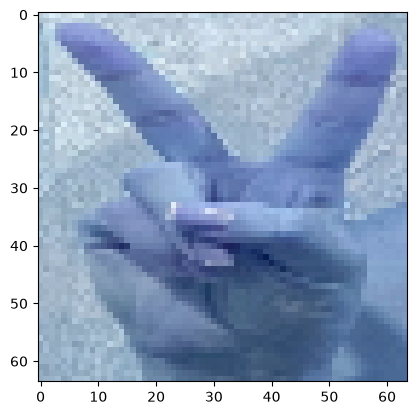

In [6]:
plt.imshow(random.sample(images, 1)[0])
#plt.imshow(random.sample(images, 1)[0], cmap='gray')

## split data set into train and test

x is for the actual data, y is for the label (this is convention)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

778
195
778
195


## transform data sets into a format compatible with our neural network

image data has to be a numpy array with following dimensions: [image_id, y_axis, x_axis, color_channels]

furthermore, scale all values to a range of 0 to 1

training data has to be converted to a categorial vector ("one hot"):

[3] --> [0, 0, 0, 1, 0, ..., 0]

In [8]:
# Convert to float
X_train = np.array(X_train).astype('float32')
# Normalization [0,1]
X_train = X_train / 255.

X_test = np.array(X_test).astype('float32')
X_test = X_test / 255.


# Convert interger class labels in to one hot vector
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

# rename for demonstration purposes
train_label = y_train_one_hot
test_label = y_test_one_hot

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

print(X_train.shape, X_test.shape, train_label.shape, test_label.shape)

(778, 64, 64, 3) (195, 64, 64, 3) (778, 4) (195, 4)


In [9]:
# variables for hyperparameters
batch_size = 8 
epochs = 50 
num_classes = len(label_names)
activation = 'relu'
activation_conv = 'leaky_relu'
layer_count = 2
num_neurons = 16

# define model structure
# with keras, we can use a model's add() function to add layers to the network one by one
model = Sequential()

# data augmentation (this can also be done beforehand - but don't augment the test dataset!)
model.add(RandomFlip('horizontal'))
model.add(RandomContrast(0.1))
#model.add(RandomBrightness(0.1))
#model.add(RandomRotation(0.2))

# first, we add some convolution layers followed by max pooling
model.add(Conv2D(64, kernel_size=(9, 9), activation=activation_conv, input_shape=(SIZE[0], SIZE[1], COLOR_CHANNELS), padding='same'))
model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

model.add(Conv2D(32, (5, 5), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))

model.add(Conv2D(32, (3, 3), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

# Randomly disables 20% of neurons during each training step
model.add(Dropout(0.2))

# after the convolution layers, we have to flatten the data so it can be fed into fully connected layers
model.add(Flatten())

# add some fully connected layers ("Dense")
for i in range(layer_count - 1):
    model.add(Dense(num_neurons, activation=activation))

model.add(Dense(num_neurons, activation=activation))

# for classification, the last layer has to use the softmax activation function, which gives us probabilities for each category
model.add(Dense(num_classes, activation='softmax'))

# specify loss function, optimizer and evaluation metrics
# for classification, categorial crossentropy is used as a loss function
# use the adam optimizer unless you have a good reason not to
model.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])

# define callback functions that react to the model's behavior during training
# in this example, we reduce the learning rate once we get stuck and early stopping
# to cancel the training if there are no improvements for a certain amount of epochs

# If validation loss stops improving for 2 epochs, multiply  the learning rate by 0.2 (slow down/fine tune)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
# if validation loss doesn't improve for 3 epchs, stop training entierly
stop_early = EarlyStopping(monitor='val_loss', patience=3)

/Users/anjafranke/InteractionTechniques/Assignment5/assignment-05-cnn-Anja0901/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## now, we can train the model using the fit() function
## this will take a while

In [10]:
history = model.fit(
    X_train,
    train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, test_label),
    callbacks=[reduce_lr, stop_early]
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 24s 188ms/step - accuracy: 0.2609 - loss: 1.3886 - val_accuracy: 0.2923 - val_loss: 1.3863 - learning_rate: 0.0010
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 28s 288ms/step - accuracy: 0.3316 - loss: 1.3462 - val_accuracy: 0.4821 - val_loss: 1.3084 - learning_rate: 0.0010
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 32s 323ms/step - accuracy: 0.4113 - loss: 1.2026 - val_accuracy: 0.4872 - val_loss: 1.0879 - learning_rate: 0.0010
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 24s 239ms/step - accuracy: 0.5437 - loss: 0.9977 - val_accuracy: 0.6564 - val_loss: 0.8781 - learning_rate: 0.0010
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 19s 196ms/step - accuracy: 0.6979 - loss: 0.7422 - val_accuracy: 0.7538 - val_loss: 0.6136 - learning_rate: 0.0010
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 25s 256ms/step - accuracy: 0.7558 - loss: 0.6221 - val_accuracy: 0.8821 - val_loss: 0.4262 - learning_rate: 0.0010
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 23s 232ms/step - accuracy: 0.7956 - loss: 0.

In [11]:
# let's have a look at our model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 64, 64, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,182 (949.93 KB)

 Trainable params: 81,060 (316.64 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 162,122 (633.29 KB)

## Plot accuracy and loss of the training process

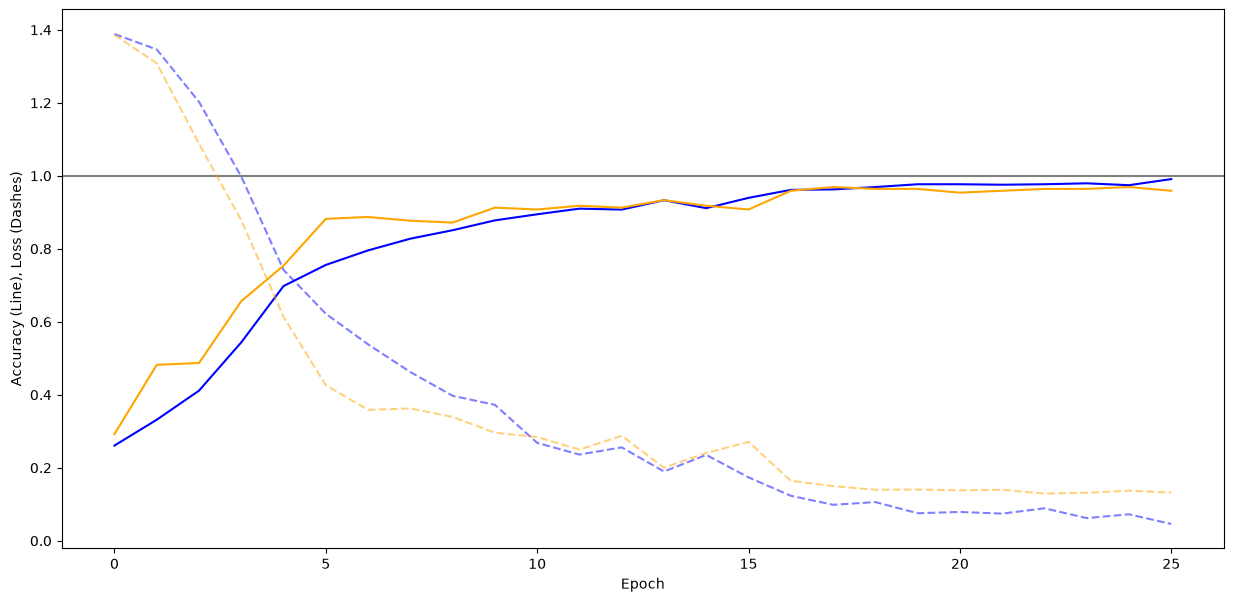

In [12]:
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (Line), Loss (Dashes)')

ax.axhline(1, color='gray')

plt.plot(accuracy, color='blue')
plt.plot(val_accuracy, color='orange')
plt.plot(loss, '--', color='blue', alpha=0.5)
plt.plot(val_loss, '--', color='orange', alpha=0.5)

## saving the model

the function will create a directory for your model and save structure and weights in there

sometimes you will see the .h5 format being used - even though this is a bit faster and needs less space, it comes with its limitations and isn't used that much any more

In [13]:
model.save('gesture_recognition.keras')

# and this is how you load the model
# model = keras.models.load_model("gesture_recognition.keras")

## visualize classification results with a confusion matrix

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 296ms/step
Inference Time (gesamt): 3.184427160973428 Sekunden
Inference Time pro Bild: 0.01633039569729963 Sekunden
before [[9.99440551e-01 3.70794842e-05 4.61070528e-07 5.21799666e-04]
 [6.69870687e-11 7.86173987e-05 9.99702215e-01 2.19210269e-04]
 [6.38608908e-05 9.99873638e-01 5.60042245e-05 6.44612373e-06]
 [6.39277520e-18 5.45392425e-08 9.99998868e-01 1.08159566e-06]
 [9.91812825e-01 1.48711272e-03 7.28510204e-05 6.62712567e-03]
 [6.19449934e-12 1.77588183e-04 9.99803782e-01 1.85960271e-05]
 [8.06138152e-04 6.33866584e-05 1.11201974e-02 9.88010168e-01]
 [1.82933593e-06 2.58578383e-03 9.72584963e-01 2.48275008e-02]
 [9.99462485e-01 2.44400901e-04 3.33460548e-06 2.89837422e-04]
 [9.91544664e-01 1.56582973e-04 2.33414667e-05 8.27551354e-03]
 [2.17077832e-04 1.00195676e-03 2.52905935e-01 7.45875001e-01]
 [1.13244765e-02 9.30797875e-01 3.88243683e-02 1.90532822e-02]
 [9.99991000e-01 2.09019987e-07 5.96446448e-10 8.71206248e-06]
 [1.84110668e-03 9.98143554e-

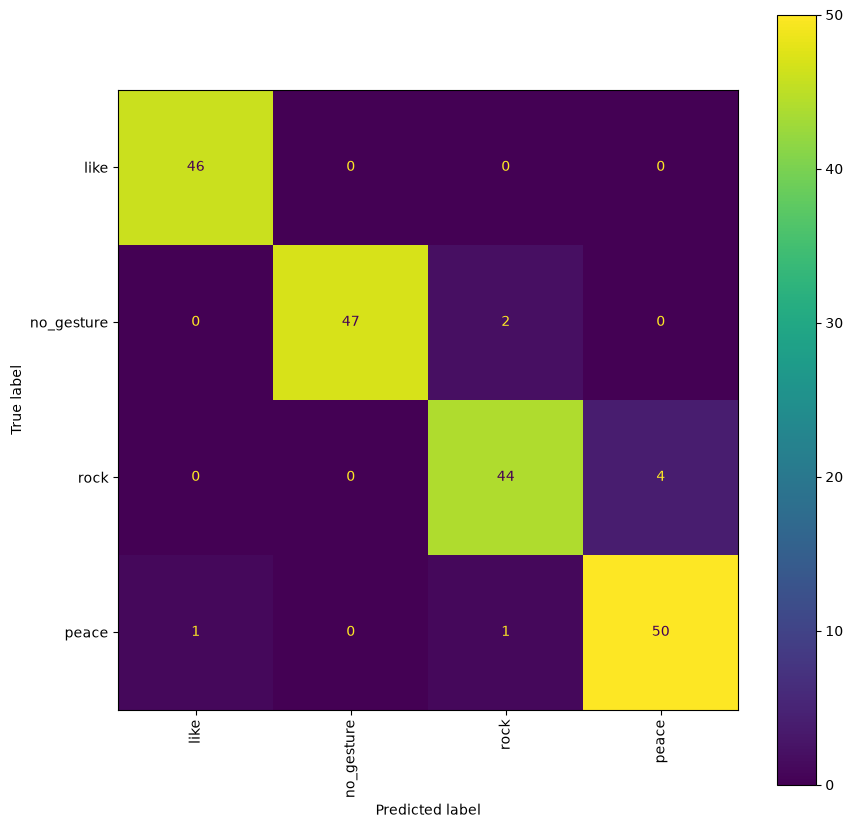

In [14]:
import time

start = time.perf_counter()

# let the model make predictions for our test data
y_predictions = model.predict(X_test)

end = time.perf_counter()

inference_time = end - start

print("Inference Time (gesamt):", inference_time, "Sekunden")
print("Inference Time pro Bild:", inference_time / len(X_test), "Sekunden")

# we get a 2D numpy array with probabilities for each category
print('before', y_predictions)

# to build a confusion matrix, we have to convert it to classifications
# this can be done by using the argmax() function to set the probability to 1 and the rest to 0
y_predictions = np.argmax(y_predictions, axis=1)

print('probabilities', y_predictions)

# create and plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_predictions)

fig = plt.figure(figsize=(10, 10))

ConfusionMatrixDisplay(conf_matrix, display_labels=label_names).plot(ax=plt.gca())

plt.xticks(rotation=90, ha='center')
pass

Aufgabe 2

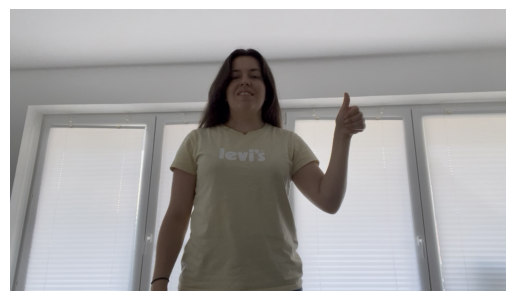

In [16]:
# eigene Bilder laden
from matplotlib import pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("../02-dataset/anja_images/2bd068d8-54d3-4ac0-bc10-a19fc9069d87.jpg")

plt.imshow(img)
plt.axis("off")
plt.show()

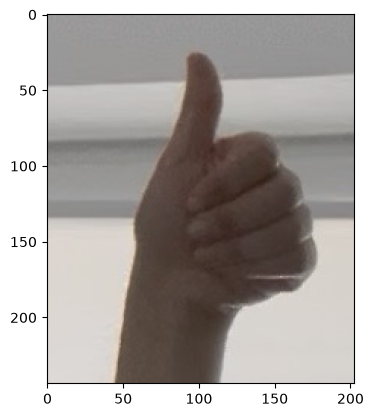

In [18]:

import json

with open("../02-dataset/anja_images/annot-anja.json") as f:
    data = json.load(f)

img = cv2.imread("../02-dataset/anja_images/2bd068d8-54d3-4ac0-bc10-a19fc9069d87.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


h, w = img.shape[:2]

entry = data["2bd068d8-54d3-4ac0-bc10-a19fc9069d87"]

for bbox in entry["bboxes"]:
    x, y, bw, bh = bbox

    x_l = int(x * w)
    y_t = int(y * h)

    bw_px = int(bw * w)
    bh_px = int(bh * h)

    x_r = x_l + bw_px
    y_b = y_t + bh_px

    cropped = img[ y_t:y_b,x_l:x_r]
    plt.imshow(cropped)




  0%|          | 0/4 [00:00<?, ?it/s]

 75%|███████▌  | 3/4 [00:00<00:00, 17.33it/s]

'annot-anja'


 29%|██▊       | 2/7 [00:00<00:00, 14.92it/s]

'annot-tutors'


100%|██████████| 7/7 [00:00<00:00,  9.17it/s]


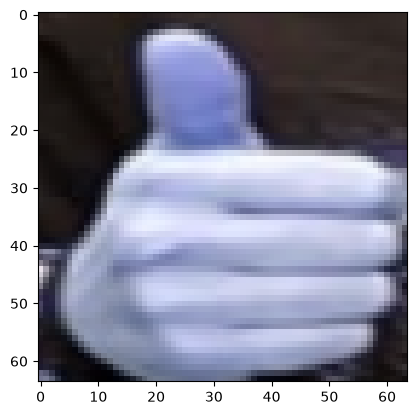

In [19]:
images = [] # stores actual image data
labels = [] # stores labels (as integer - because this is what our network needs)
label_names = [] # maps label ints to their actual categories so we can understand predictions later

PATH = '../02-dataset'

annotations = dict()

JSONS = [
    ['anja_images','annot-anja'],
    ['tutor_images','annot-tutors']
]

for json_location in JSONS:
    with open(f'{PATH}/{json_location[0]}/{json_location[1]}.json') as f:
        annotations[json_location[0]] = json.load(f)

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for json_location in JSONS:
    for filename in tqdm(os.listdir(f'{PATH}/{json_location[0]}')):
        # extract unique ID from file name
        UID = filename.split('.')[0]
        img = cv2.imread(f'{PATH}/{json_location[0]}/{filename}')
        
        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[json_location[0]][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            # get the annotated hand's label
            # if we have not seen this label yet, add it to the list of labels
            label = annotation['labels'][i]
            if label not in label_names:
                label_names.append(label)
            
            label_index = label_names.index(label)
            
            images.append(preprocessed)
            labels.append(label_index)

plt.imshow(random.sample(images, 1)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
before [[5.7549596e-01 2.7695164e-01 3.8809725e-03 1.4367147e-01]
 [2.8343646e-07 3.1911184e-06 7.9307690e-02 9.2068887e-01]
 [4.4552900e-04 4.3728869e-07 2.2677449e-04 9.9932724e-01]
 [4.5888482e-06 6.3323188e-01 3.6531591e-01 1.4475088e-03]
 [1.6921148e-06 1.1096509e-09 6.6581917e-05 9.9993163e-01]
 [6.7237452e-11 9.9999982e-01 1.1284929e-07 2.3414781e-11]
 [1.1482364e-13 8.5445936e-07 9.9988228e-01 1.1679800e-04]
 [4.1559640e-09 9.9999994e-01 2.7946950e-08 7.6140920e-11]
 [8.0786139e-02 1.9242009e-03 2.8749062e-03 9.1441476e-01]
 [3.7137497e-08 1.0000000e+00 2.0140304e-08 3.4837408e-10]
 [9.9999988e-01 4.1980934e-09 1.3641859e-12 1.4873524e-07]
 [3.5882388e-09 1.0000000e+00 1.6286449e-09 1.1497096e-11]
 [9.6966624e-01 5.6388886e-03 3.2913795e-04 2.4365768e-02]
 [3.4209333e-11 9.9999952e-01 4.7388139e-07 1.4302091e-10]]
probabilities [0 3 3 1 3 1 2 1 3 1 0 1 0 1]


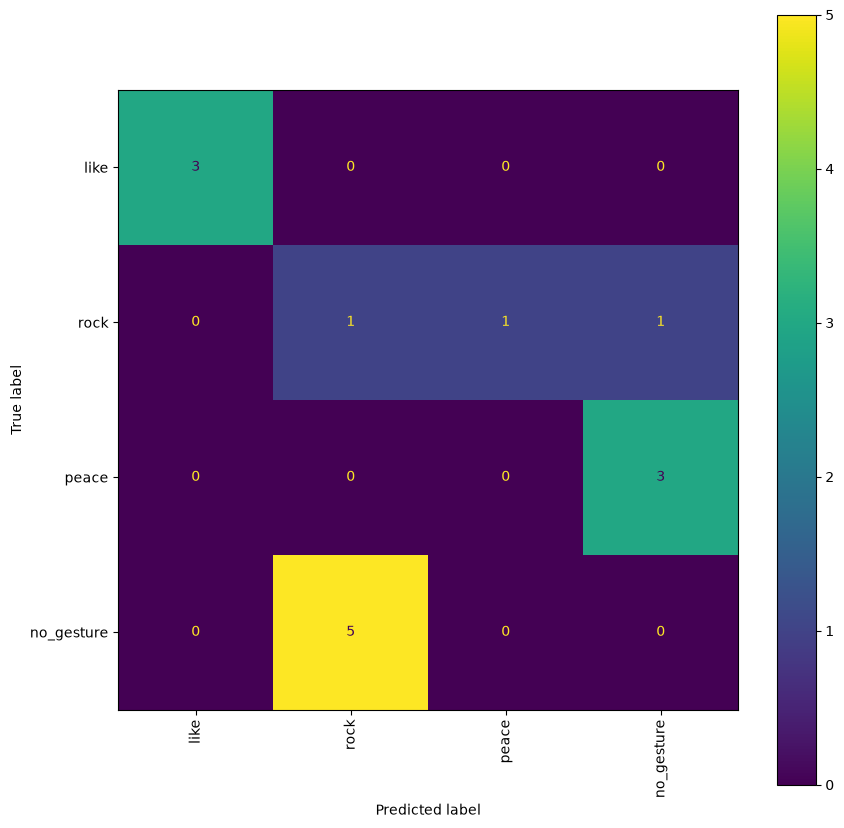

In [20]:
images = np.array(images).astype('float32')

images = images / 255.

# let the model make predictions for our test data
y_predictions = model.predict(images)



# we get a 2D numpy array with probabilities for each category
print('before', y_predictions)

# to build a confusion matrix, we have to convert it to classifications
# this can be done by using the argmax() function to set the probability to 1 and the rest to 0
y_predictions = np.argmax(y_predictions, axis=1)

print('probabilities', y_predictions)

# create and plot confusion matrix
conf_matrix = confusion_matrix(labels, y_predictions)

fig = plt.figure(figsize=(10, 10))

ConfusionMatrixDisplay(conf_matrix, display_labels=label_names).plot(ax=plt.gca())

plt.xticks(rotation=90, ha='center')
pass